# Transform methods: half-line Schrödinger evolution

We use the unified-transform implementation on $i u_t+u_{xx}=0$ for $x>0$ with homogeneous Dirichlet boundary data. The emphasis is on recognizing the dispersion relation and understanding when a transform representation is semantically complete.

**Tutorial contract.** This notebook derives the mathematics, asks PDESolve how it recognizes/plans the problem, executes the solver, independently checks the returned mathematics where appropriate, visualizes the solution or its structure, and ends with runnable variations plus exercises.

In [1]:
from pathlib import Path
import sys

# Make a source checkout importable without requiring an editable install.
root = Path.cwd().resolve()
for candidate in [root, *root.parents]:
    if (candidate / "pdesolve").is_dir():
        ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate the pdesolve source tree")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pdesolve as pds
from IPython.display import display

sp.init_printing()
print("PDESolve source:", ROOT)
print("SymPy:", sp.__version__)

PDESolve source: /mnt/data/pdesolve_doc22SymPy: 1.14.0

In [2]:
def show_plan(problem, n=6):
    """Display recognizer output and the highest-ranked canonical plan steps."""
    rec = pds.recognize_canonical_problem(problem)
    plan = pds.plan_canonical_problem(problem)
    print("Recognition:", rec)
    print("Top plan steps:")
    for step in plan.steps[:n]:
        print(f"  {step.method:42s} score={step.score}")
    return rec, plan


def rhs_of(solution):
    """Extract the RHS of an Eq result, or return an expression unchanged."""
    return solution.rhs if isinstance(solution, sp.Equality) else solution


def residual(eq, dependent, candidate):
    """Classical residual after replacing the dependent function by candidate."""
    expr = eq.lhs - eq.rhs if isinstance(eq, sp.Equality) else eq
    return sp.simplify(expr.subs(dependent, candidate).doit())

## 1. Fourier-mode DerivationInsert a mode $u=e^{ikx-i\omega t}$ into$$i u_t+u_{xx}=0.$$Then $\omega-k^2=0$, so$$\boxed{\omega(k)=k^2}.$$On a half-line, the boundary condition prevents using the whole-line Fourier formula unchanged; the unified transform packages the boundary-compatible spectral representation.

In [3]:
x,t,k=sp.symbols("x t k", positive=True, real=True)
u=sp.Function("u")
eq=sp.Eq(sp.I*sp.diff(u(x,t),t)+sp.diff(u(x,t),x,2),0)
ic=sp.Eq(u(x,0),sp.sin(x)); bc=[sp.Eq(u(0,t),0)]
problem=pds.build_pde_problem(eq,u(x,t),(x,t),ics=ic,bcs=bc)
recognition, plan=show_plan(problem)
profile=pds.recognize_evolution_pde(eq,u,(x,t))
print("Evolution family:",profile.family_name)
print("Dispersion metadata:", pds.determine_dispersion_relation(eq, u, (x,t)))

Recognition: (PDERecognitionRecord(family='heat_like', recognized=True, solver_hint='heat_dirichlet_series', tags=('separation_of_variables', 'integral_transform'), metadata={}),)Top plan steps:  constant_coefficient_inverse_operator      score=84  structured_transform                       score=77  heat_dirichlet_series                      score=70  symmetry_reduction                         score=60  post_reduction_auto                        score=48  classification_only                        score=20Evolution family: schrodinger_like

Dispersion metadata: I*k**2

UnifiedTransformResultmethod_family: unified_transform_half_line_schrodinger_dirichlet_zero is_formal: False

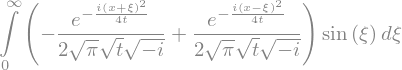

In [4]:
result=pds.solve_unified_transform(eq,u,(x,t),initial_condition=ic,boundary_conditions=bc,domain="half_line")
print(type(result).__name__)
print("method_family:",result.method_family,"is_formal:",result.is_formal)
display(result.solution)
assert profile.family_name == "schrodinger_like"
assert result.is_formal is False
assert "schrodinger" in result.method_family

## 2. Verification semanticsThe returned integral representation is a native supported half-line Schrödinger result (`is_formal=False`). Transform-family verification can be structural when symbolic inversion or simplification is not cheap; it need not reduce every integral to an elementary expression.

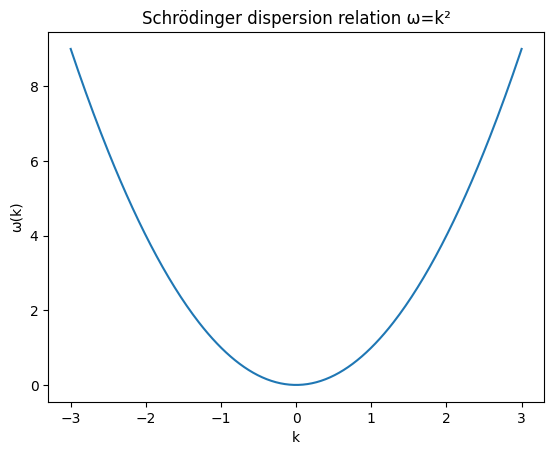

In [5]:
kk=np.linspace(-3,3,300)
fig,ax=plt.subplots(); ax.plot(kk,kk**2)
ax.set_xlabel("k"); ax.set_ylabel("ω(k)"); ax.set_title("Schrödinger dispersion relation ω=k²"); plt.show()

## 3. Variation and exercisesAsk PDESolve to recognize the heat equation as an evolution PDE below. Then: (1) derive its Fourier dispersion/decay factor; (2) compare whole-line and half-line geometry; (3) explain the difference between a formal transform result and a native implemented inversion/representation.

In [6]:
heat=sp.Eq(sp.diff(u(x,t),t)-sp.diff(u(x,t),x,2),0)
hp=pds.recognize_evolution_pde(heat,u,(x,t))
print(hp)

EvolutionPDEProfile(family_name='heat_like', order_x=2, time_coefficient=1, coeffs={2: -1}, dispersion_relation=k**2, notes='Second-order parabolic heat/advection-diffusion family.')